# Assignment 4: Semi-structured Data

Parsing gait analysis reports, chest X-ray XML reports, and FHIR EHR records, plus LLM-based structured extraction.

In [4]:
import io
import os
import glob
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import requests

GAIT_DIR = os.path.join("gait", "gait")
EMR_DIR = os.path.join("emr", "emr")

## Problem 1: Parsing a Real-World Biomechanics Report

In [5]:
def parse_gait_file(filepath):
    with open(filepath, encoding="utf-8-sig") as f:
        lines = f.readlines()

    data_start_idx = 0
    for i, line in enumerate(lines):
        if "Step Ratio" in line:
            data_start_idx = i
            break

    header = {}
    for line in lines[:data_start_idx]:
        line = line.rstrip("\n")
        if not line.strip():
            continue
        parts = line.split(";", 1)
        key = parts[0].strip()
        value = parts[1].strip().strip(",").strip() if len(parts) > 1 else ""
        header[key] = value

    data_lines = [line.rstrip("\n") for line in lines[data_start_idx:] if line.strip()]
    data_str = "\n".join(data_lines)
    gait_df = pd.read_csv(io.StringIO(data_str), sep=";")

    gait_df = gait_df.rename(columns={gait_df.columns[0]: "metric", gait_df.columns[1]: "foot"})
    gait_df["foot"] = gait_df["foot"].fillna("LR_mean")
    gait_df = gait_df.dropna(axis=1, how="all")

    return header, gait_df

In [6]:
gait_header, gait_df = parse_gait_file(os.path.join(GAIT_DIR, "gait_session.txt"))

print(gait_header)
gait_df

{'First Name': '', 'Last Name': '', 'Full Name': '', 'Gender': 'Male', 'Age': '', 'Reference': '', 'Trial Time': '10/11/2024 3:32:55 PM', 'Comment 1': '', 'Comment 2': '', 'Height': '', 'Weight': '', 'Left Leg Length': '', 'Right Leg Length': '', 'Partition Line': '********************', 'Video File': 'vid0006_0005', 'Subject Number': '123456'}


,metric,foot,Step Ratio (cm. x min.),First Contact (sec.),Last Contact (sec.),Integ. Pressure (p x sec.),Foot Length (cm.),Foot Length %,Foot Width (cm.),Foot Area (cm. x cm.),...,Stance COP Path Eff. %,SS COP Path Eff. %,DS COP Path Eff.%,Velocity (cm./sec.),Ambulation Time (sec.),Cadence (steps/min.),Mean eGVI,Left eGVI,Right eGVI,Walk Ratio (cm./(steps/min.))
0,#Samples,LR_mean,14.000,18.000,18.000,18.000,18.000,18.000,18.000,18.000,...,18.000,14.000,16.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,#Samples,Left,8.000,10.000,10.000,10.000,10.000,10.000,10.000,10.000,...,10.000,6.000,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,#Samples,Right,6.000,8.000,8.000,8.000,8.000,8.000,8.000,8.000,...,8.000,8.000,8.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Mean,LR_mean,0.626,11.412,12.177,252.750,31.767,96.349,11.746,292.985,...,95.660,98.983,99.983,113.133,9.242,103.877,94.895,100.0,89.791,0.627
4,Mean,Left,0.625,11.413,12.182,249.257,31.744,97.410,11.642,290.064,...,95.970,99.336,99.989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Mean,Right,0.626,11.410,12.171,257.115,31.797,95.021,11.877,296.636,...,95.273,98.719,99.978,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Ratio,L/R,0.999,1.000,1.001,0.969,0.998,1.025,0.980,0.978,...,1.007,1.006,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ASI,LR_mean,0.068,-0.026,-0.089,3.103,0.168,-2.483,2.004,2.240,...,-0.729,-0.624,-0.011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,S.D.,LR_mean,0.022,4.006,4.003,21.681,0.665,2.346,0.591,14.372,...,1.269,0.788,0.016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,S.D.,Left,0.028,4.162,4.161,27.735,0.535,1.641,0.705,15.017,...,1.195,0.133,0.014,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
expected_df = pd.read_csv(os.path.join(GAIT_DIR, "processed_gait_file.csv"))

assert list(gait_df.columns) == list(expected_df.columns)
assert list(zip(gait_df["metric"], gait_df["foot"])) == list(zip(expected_df["metric"], expected_df["foot"]))
print("gait_df matches the structure (columns and metric/foot row labels) of the expected processed_gait_file.csv")

gait_df matches the structure (columns and metric/foot row labels) of the expected processed_gait_file.csv


## Problem 2: Visualizing Gait Symmetry

In [8]:
def plot_gait_comparison(gait_df, parameters_to_plot, metric):
    metric_df = gait_df[gait_df["metric"] == metric]
    left_row = metric_df[metric_df["foot"] == "Left"].iloc[0]
    right_row = metric_df[metric_df["foot"] == "Right"].iloc[0]

    left_values = left_row[parameters_to_plot].astype(float)
    right_values = right_row[parameters_to_plot].astype(float)

    x = np.arange(len(parameters_to_plot))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width / 2, left_values, width, label="Left")
    ax.bar(x + width / 2, right_values, width, label="Right")

    ax.set_title(f"Gait Comparison for {metric} Values")
    ax.set_xlabel("Gait Parameter")
    ax.set_ylabel(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(parameters_to_plot, rotation=45, ha="right")
    ax.legend()

    fig.tight_layout()
    plt.show()

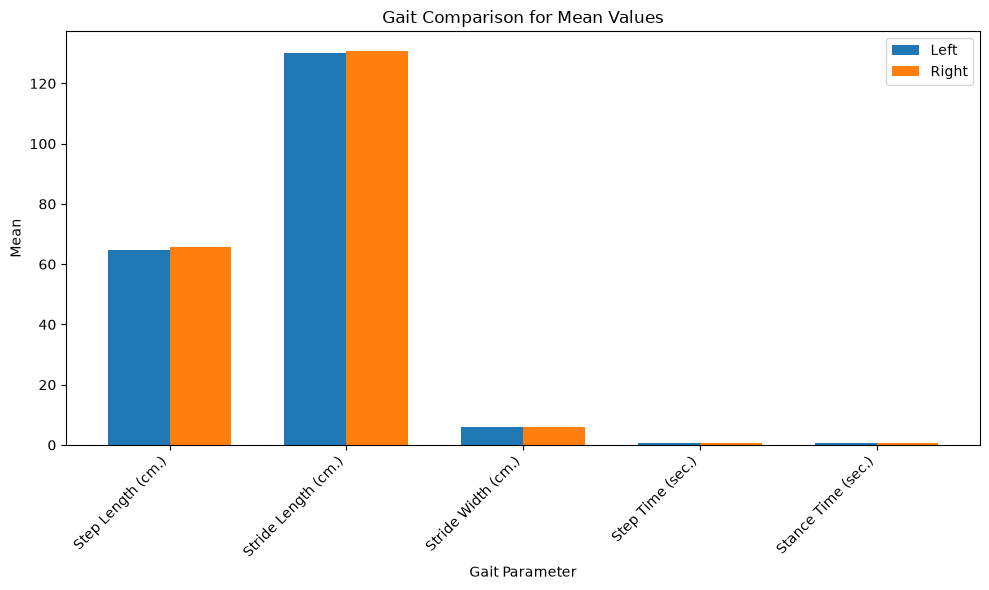

In [9]:
parameters_to_plot = [
    "Step Length (cm.)",
    "Stride Length (cm.)",
    "Stride Width (cm.)",
    "Step Time (sec.)",
    "Stance Time (sec.)",
]

plot_gait_comparison(gait_df, parameters_to_plot, "Mean")

## Problem 3: Parsing Medical Reports from XML

In [10]:
def parse_single_report(filepath):
    root = ET.parse(filepath).getroot()

    uid_elem = root.find(".//uId")
    uid = uid_elem.get("id") if uid_elem is not None else None

    abstract_sections = {"COMPARISON": None, "INDICATION": None, "FINDINGS": None, "IMPRESSION": None}
    for abstract_text in root.findall(".//AbstractText"):
        label = abstract_text.get("Label")
        if label in abstract_sections:
            abstract_sections[label] = abstract_text.text

    image_ids = [img.get("id") for img in root.findall(".//parentImage")]

    return {
        "uId": uid,
        "Comparison": abstract_sections["COMPARISON"],
        "Indication": abstract_sections["INDICATION"],
        "Findings": abstract_sections["FINDINGS"],
        "Impression": abstract_sections["IMPRESSION"],
        "Image_IDs": image_ids,
    }


def process_xml_directory(directory_path):
    records = [parse_single_report(fp) for fp in glob.glob(os.path.join(directory_path, "*.xml"))]
    return pd.DataFrame(records)

In [11]:
rad_reports_df = process_xml_directory(os.path.join(EMR_DIR, "rad_reports"))

print(rad_reports_df.shape)
rad_reports_df[rad_reports_df["uId"] == "CXR98"]

(118, 6)


,uId,Comparison,Indication,Findings,Impression,Image_IDs
96,CXR98,"XXXX, XXXX.",Chest pain shortness of breath for 3 days. The...,Frontal and lateral views of the chest show an...,"No acute or active cardiac, pulmonary or pleur...","[CXR98_IM-2467-1001, CXR98_IM-2467-4004]"


## Problem 4: Generating Structured Prompts for LLM-Based Data Extraction

In [12]:
CARDIO_DIAGNOSES = ["cardiomegaly", "vascular_congestion", "atherosclerosis", "normal", "other", "not_evaluated"]
PULMONARY_DIAGNOSES = ["atelectasis", "consolidation", "effusion", "nodule", "infectious", "normal", "other", "not_evaluated"]


def generate_llm_prompt(report_row):
    prompt = f"""You are an expert medical coding assistant. Your task is to analyze the following sections of a chest X-ray radiology report and determine the single primary cardiological diagnosis and the single primary pulmonary diagnosis.

--- REPORT TEXT ---
COMPARISON: {report_row['Comparison']}
INDICATION: {report_row['Indication']}
FINDINGS: {report_row['Findings']}
IMPRESSION: {report_row['Impression']}
--- END REPORT TEXT ---

Please adhere to the following rules:
1.  Choose exactly one diagnosis for the heart/cardiovascular system from this list: {CARDIO_DIAGNOSES}.
2.  Choose exactly one diagnosis for the lungs/pulmonary system from this list: {PULMONARY_DIAGNOSES}.
3.  Use 'normal' if the organ system is described as unremarkable or without acute findings.
4.  Use 'other' only if a clear diagnosis is stated that is not on the provided list.
5.  Use 'not_evaluated' if the report does not contain enough information to make a judgment about that organ system.

Your response MUST be a single, valid JSON object and nothing else. Do not include any explanations or introductory text.

Format your response as follows:
{{"cardio_diag": "your_cardio_diagnosis", "pulmonary_diag": "your_pulmonary_diagnosis"}}"""
    return prompt

In [13]:
example_row = rad_reports_df[rad_reports_df["uId"] == "CXR98"].iloc[0]
example_prompt = generate_llm_prompt(example_row)
print(example_prompt)

You are an expert medical coding assistant. Your task is to analyze the following sections of a chest X-ray radiology report and determine the single primary cardiological diagnosis and the single primary pulmonary diagnosis.

--- REPORT TEXT ---
COMPARISON: XXXX, XXXX.
INDICATION: Chest pain shortness of breath for 3 days. The patient's lower abdomen was shielded for this exam.
FINDINGS: Frontal and lateral views of the chest show an unchanged cardiomediastinal silhouette. Reduced lung volumes with basilar atelectasis. No XXXX focal airspace consolidation or pleural effusion.
IMPRESSION: No acute or active cardiac, pulmonary or pleural disease.
--- END REPORT TEXT ---

Please adhere to the following rules:
1.  Choose exactly one diagnosis for the heart/cardiovascular system from this list: ['cardiomegaly', 'vascular_congestion', 'atherosclerosis', 'normal', 'other', 'not_evaluated'].
2.  Choose exactly one diagnosis for the lungs/pulmonary system from this list: ['atelectasis', 'conso

## Problem 5: Extracting Structured Data with a Chat Completions API

In [ ]:
hf_token = "" #sorry, I don't want to put this out there. Please see outputs below to show it worked

In [15]:
API_URL = "https://router.huggingface.co/v1/chat/completions"


def query(payload, hf_token):
    headers = {"Authorization": f"Bearer {hf_token}"}
    response = requests.post(API_URL, headers=headers, json=payload)
    return response.json()

In [16]:
payload = {
    "messages": [{"role": "user", "content": example_prompt}],
    "model": "openai/gpt-oss-120b",
}

raw_response = query(payload, hf_token)
raw_response

{'id': 'chatcmpl-55e2373b-2934-462b-ac44-72baf5010898',
 'choices': [{'finish_reason': 'stop',
   'index': 0,
   'message': {'content': '{"cardio_diag": "normal", "pulmonary_diag": "atelectasis"}',
    'reasoning': 'We need to extract primary cardiological and pulmonary diagnosis.\n\nReport says: "unchanged cardiomediastinal silhouette" => no mention of enlargement, so likely normal. No acute cardiac disease.\n\nPulmonary: "Reduced lung volumes with basilar atelectasis." That\'s atelectasis. No consolidation or effusion. So pulmonary diagnosis is atelectasis.\n\nThus cardio_diag = "normal". pulmonary_diag = "atelectasis".\n\nCheck if any other conditions: "No acute or active cardiac, pulmonary or pleural disease." But still there is atelectasis (which is a chronic condition?). It\'s noted, so it\'s a diagnosis albeit not acute. They have atelectasis, not normal. So "atelectasis" is appropriate.\n\nThus JSON.',
    'role': 'assistant'}}],
 'created': 1788208063,
 'model': 'gpt-oss-120b'

In [17]:
def get_llm_diagnoses(prompt, api_token):
    payload = {
        "messages": [{"role": "user", "content": prompt}],
        "model": "openai/gpt-oss-120b",
    }

    response = query(payload, api_token)

    try:
        content = response["choices"][0]["message"]["content"]
        json_start = content.index("{")
        json_end = content.rindex("}")
        json_string = content[json_start:json_end + 1]
        return json.loads(json_string)
    except (KeyError, IndexError, ValueError):
        return None

In [18]:
diagnoses = get_llm_diagnoses(example_prompt, hf_token)
diagnoses

{'cardio_diag': 'normal', 'pulmonary_diag': 'atelectasis'}

## Problem 6: Electronic Health Records (FHIR)

In [19]:
def parse_single_patient_record(data):
    resources = [entry["resource"] for entry in data.get("entry", [])]

    patient = None
    for r in resources:
        if r["resourceType"] == "Patient":
            patient = r
            break

    encounters = [r for r in resources if r["resourceType"] == "Encounter"]

    name = patient.get("name", [{}])[0]
    given_name = name.get("given", [None])[0]
    family_name = name.get("family")

    mrn = None
    for identifier in patient.get("identifier", []):
        if identifier.get("type", {}).get("text") == "Medical Record Number":
            mrn = identifier.get("value")
            break

    dob = patient.get("birthDate")
    gender = patient.get("gender")

    birth_sex = None
    race = None
    ethnicity = None
    for ext in patient.get("extension", []):
        url = ext.get("url", "")
        if "us-core-birthsex" in url:
            birth_sex = ext.get("valueCode")
        elif "us-core-race" in url:
            for sub_ext in ext.get("extension", []):
                if sub_ext.get("url") == "ombCategory":
                    race = sub_ext.get("valueCoding", {}).get("display")
        elif "us-core-ethnicity" in url:
            for sub_ext in ext.get("extension", []):
                if sub_ext.get("url") == "ombCategory":
                    ethnicity = sub_ext.get("valueCoding", {}).get("display")

    addresses = patient.get("address", [])
    home_address = None
    for a in addresses:
        if a.get("use") == "home":
            home_address = a
            break
    if home_address is None:
        home_address = addresses[0] if addresses else {}

    city = home_address.get("city")
    state = home_address.get("state")

    dod = patient.get("deceasedDateTime")
    dob_date = datetime.fromisoformat(dob).date()

    if dod:
        dod_date = datetime.fromisoformat(dod).date()
        age_at_death = (dod_date - dob_date).days / 365.25
        current_age = np.nan
    else:
        age_at_death = np.nan
        current_age = (datetime.now().date() - dob_date).days / 365.25

    encounter_reasons = []
    for encounter in encounters:
        for reason in encounter.get("reasonCode", []):
            codings = reason.get("coding", [])
            if codings:
                encounter_reasons.append(codings[0].get("display"))

    return {
        "given_name": given_name,
        "family_name": family_name,
        "mrn": mrn,
        "dob": dob,
        "gender": gender,
        "birth_sex": birth_sex,
        "race": race,
        "ethnicity": ethnicity,
        "city": city,
        "state": state,
        "dod": dod,
        "age_at_death": age_at_death,
        "current_age": current_age,
        "encounter_reasons": encounter_reasons,
    }


def process_fhir_directory(directory_path):
    records = []
    for filepath in glob.glob(os.path.join(directory_path, "*.json")):
        with open(filepath, encoding="utf-8") as f:
            data = json.load(f)
        records.append(parse_single_patient_record(data))
    return pd.DataFrame(records)

In [20]:
fhir_df = process_fhir_directory(os.path.join(EMR_DIR, "fhir"))

print(fhir_df.shape)
fhir_df.head()

(1180, 14)


,given_name,family_name,mrn,dob,gender,birth_sex,race,ethnicity,city,state,dod,age_at_death,current_age,encounter_reasons
0,Aaron697,Brekke496,2fa15bc7-8866-461a-9000-f739e425860a,1945-12-10,male,M,White,Not Hispanic or Latino,Taunton,Massachusetts,NaN,NaN,80.722793,"[Viral sinusitis (disorder), Viral sinusitis (..."
1,Aaron697,Stiedemann542,41166989-975d-4d17-b9de-17f94cb3eec1,1946-03-29,male,M,White,Not Hispanic or Latino,Westford,Massachusetts,NaN,NaN,80.424367,"[Viral sinusitis (disorder), Acute bronchitis ..."
2,Abby752,Kuvalis369,2b083021-e93f-4991-bf49-fd4f20060ef8,2002-10-24,female,F,White,Not Hispanic or Latino,Wakefield,Massachusetts,NaN,NaN,23.852156,[Otitis media]
3,Abel832,Connelly992,29e51479-f742-4474-8f8e-d2607d5269f6,1999-12-12,male,M,White,Not Hispanic or Latino,Northbridge,Massachusetts,NaN,NaN,26.718686,"[Sinusitis (disorder), Acute bronchitis (disor..."
4,Abraham100,Heller342,262b819a-5193-404a-9787-b7f599358035,2002-04-15,male,M,White,Not Hispanic or Latino,Somerville,Massachusetts,NaN,NaN,24.377823,"[Viral sinusitis (disorder), Acute viral phary..."
